In [ ]:
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

RANDOM_SEED = 694973

In [ ]:
df=pd.read_csv('shot_data.csv')
df.head(5)

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON
0,22200001,7,PT11M38.00S,1,1610612755,PHI,203954,Embiid,J. Embiid,-118,50,13,Missed,1,NaN,NaN,0,v,MISS Embiid 13' Turnaround Fadeaway Shot,Missed Shot,Turnaround Fadeaway shot,1,2,3,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
1,22200001,11,PT11M15.00S,1,1610612738,BOS,203935,Smart,M. Smart,120,55,13,Made,1,2.0,0.0,2,h,Smart 13' Driving Floating Bank Jump Shot (2 PTS),Made Shot,Driving Floating Bank Jump Shot,1,2,7,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
2,22200001,12,PT11M05.00S,1,1610612755,PHI,202699,Harris,T. Harris,50,135,14,Missed,1,NaN,NaN,0,v,MISS Harris 14' Driving Floating Jump Shot,Missed Shot,Driving Floating Jump Shot,1,2,8,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
3,22200001,14,PT11M03.00S,1,1610612755,PHI,202699,Harris,T. Harris,0,0,0,Made,1,2.0,2.0,4,v,Harris Tip Layup Shot (2 PTS),Made Shot,Tip Layup Shot,1,2,10,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23
4,22200001,15,PT10M46.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,-232,49,24,Made,1,5.0,2.0,7,h,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),Made Shot,Jump Shot,1,3,11,22200001,1.610613e+09,BOS,1.610613e+09,PHI,NaN,NaN,2022-23


In [16]:
# recode target variable to be 0 and 1
df['is_made'] = np.where(df['shotResult']=='Made',1,0)

In [ ]:
df['SHOT_DISTANCE'] = np.sqrt((df["xLegacy"]/10)**2 + (df["yLegacy"]/10)**2)
df['ANGLE'] = np.degrees(np.arctan2(df['xLegacy'].abs(), df['yLegacy']))

df = df.loc[df['ANGLE']<=120]
df = df.loc[df['SHOT_DISTANCE']<=48] # one foot past halfway
df[['SHOT_DISTANCE', 'ANGLE']].describe()

,SHOT_DISTANCE,ANGLE
count,503749.000000,503749.000000
mean,14.268822,39.897339
std,10.444766,27.576192
min,0.000000,0.000000
25%,3.361547,17.145551
50%,13.340540,36.119341
75%,25.144582,60.255119
max,47.944656,99.981829


<Axes: >

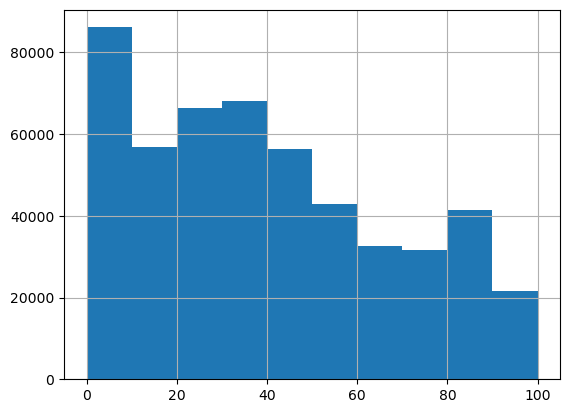

In [ ]:
df['ANGLE'].hist(bins=50)

<Axes: >

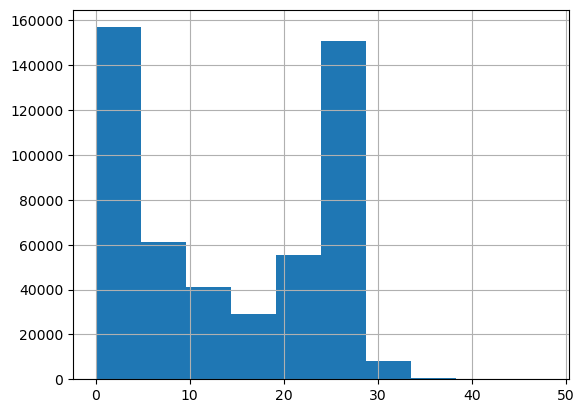

In [ ]:
df['SHOT_DISTANCE'].hist(bins=50)

In [ ]:
sub = df[['SHOT_DISTANCE','ANGLE','is_made']].reset_index(drop=True)
X = sub[['SHOT_DISTANCE','ANGLE']].values
y = sub['is_made'].values
idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, idx, test_size=0.33, random_state=RANDOM_SEED)
sub['is_train'] = sub.index.isin(idx_train).astype(int)
sub.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,1,2022-23,1,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,1,2022-23,1,Marcus Smart,203935.0,29.401780,76.0,G,2,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1
2,22200001,2,8,12,MISS Harris 14' Driving Floating Jump Shot,0,14.396180,20.323137,50,135,2,Driving Floating Jump Shot,3,JUMPER,1,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,2.0,-2.0,1,11.083333,665.0,0,1610612755,PHI,0
3,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,2,2022-23,1,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1
4,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,1,2022-23,1,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1


In [ ]:
features = ['SHOT_DISTANCE','ANGLE']
scaler = MinMaxScaler()
X_train[['distance_mm', 'angle_mm']] = scaler.fit_transform(X_train[['SHOT_DISTANCE', 'ANGLE']])
X_test[['distance_mm', 'angle_mm']] = scaler.transform(X_test[['SHOT_DISTANCE', 'ANGLE']])

sub.loc[idx_train, ['distance_mm', 'angle_mm']] = X_train[['distance_mm', 'angle_mm']]
sub.loc[idx_test, ['distance_mm', 'angle_mm']] = X_test[['distance_mm', 'angle_mm']]

In [ ]:
sub.to_csv('shot_probs_data.csv',index=False)